In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import optuna
from stable_baselines3 import PPO
from datetime import datetime
import os
from rl_system_setting import load_real_data

# --- CONFIGURATION ---
CONFIG = {
    "WINDOW_SIZE": 60,
    "TX_COST_BPS": 0.0010,
    "RISK_AVERSION": 4.0,
    "SMA_WINDOW": 50,
    "RSI_WINDOW": 14
}
SEED = 42
# === SET ALL RANDOM SEEDS FOR REPRODUCIBILITY ===
import random
random.seed(SEED)
print(f'✓ All random seeds set to {SEED}')


# === ENHANCED SEED SETTING (with PyTorch) ===
import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f'✓ PyTorch seed also set to {SEED}')

✓ All random seeds set to 42
✓ PyTorch seed also set to 42


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
class FinancialFeatureEngineer:
    def preprocess_data(self, df):
        data = df.copy()
        asset_cols = [c for c in data.columns if c != 'SPY']
        
        # 1. Log Returns
        log_ret = np.log(data[asset_cols] / data[asset_cols].shift(1)).fillna(0)
        
        # 2. Volatility
        roll_std = log_ret.rolling(20).std()
        norm_vol = (roll_std - roll_std.rolling(252).mean()) / (roll_std.rolling(252).std() + 1e-8)
        
        # 3. RSI
        delta = data[asset_cols].diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        norm_rsi = (100 - (100 / (1 + rs)) - 50) / 100 
        
        # 4. Distance from SMA (Trend)
        sma_50 = data[asset_cols].rolling(50).mean()
        dist_sma = (data[asset_cols] / sma_50) - 1.0

        # 5. RELATIVE STRENGTH (The Alpha Signal) - REPLACES BREAKOUT
        # Measures if asset is outperforming SPY over last quarter
        asset_cum = data[asset_cols].pct_change(60)
        bench_cum = data['SPY'].pct_change(60)
        rel_str = asset_cum.sub(bench_cum, axis=0)

        # Cleanup
        norm_vol = norm_vol.fillna(0).clip(-3, 3)
        norm_rsi = norm_rsi.fillna(0)
        dist_sma = dist_sma.fillna(0).clip(-0.5, 0.5)
        rel_str = rel_str.fillna(0).clip(-0.5, 0.5)
        
        # Stack 5 Features
        features = np.stack([
            norm_vol.values, 
            norm_rsi.values, 
            dist_sma.values, # Index 2
            rel_str.values,  # Index 3 (Alpha)
            log_ret.values
        ], axis=-1)
        
        return features, data[asset_cols].values, data['SPY'].values

In [3]:
class BoardOfDirectorsV3:
    def __init__(self, bull_path, bear_path, sniper_path, tickers):
        self.bull = PPO.load(bull_path)
        self.bear = PPO.load(bear_path)
        self.sniper = PPO.load(sniper_path)
        # Identify defensive assets indices to nuke them during rallies
        self.defensive_indices = [i for i, t in enumerate(tickers) if t in ['GLD', 'TLT', 'XLP', 'XLE']]
        self.hedge_indices = self.defensive_indices # Alias for compatibility
        
    def _softmax(self, x):
        e = np.exp(x - np.max(x)); return e / e.sum()

    def predict(self, obs, market_vol, avg_trend_strength, panic_vol=0.02, strong_trend=0.02):
        
        p1, _ = self.bull.predict(obs, deterministic=True)
        p2, _ = self.bear.predict(obs, deterministic=True)
        p3, _ = self.sniper.predict(obs, deterministic=True)
        wb = self._softmax(p1); wbr = self._softmax(p2); ws = self._softmax(p3)
        
        # --- LOGIC ---
        
        # 1. RALLY (Aggressive Growth)
        if avg_trend_strength > strong_trend:
            # Use 100% Bull Agent
            raw_weights = wb
            
            # FORCE AGGRESSION:
            # A. Set Cash to 0
            raw_weights[-1] = -999.0 # Logits, effectively 0 after softmax
            
            # B. Kill Defensives (GLD, TLT)
            # We want pure Tech/Growth exposure
            for idx in self.defensive_indices:
                raw_weights[idx] = -999.0
            
            # Re-Softmax to normalize
            final_weights = self._softmax(raw_weights)
            return final_weights, "RALLY (Max Aggression)"
            
        # 2. CRASH
        elif market_vol > panic_vol:
            # Same Logic: Cash is King
            cash_only = np.zeros_like(wb); cash_only[-1] = 1.0
            return cash_only, "CRASH"
            
        # 3. NORMAL (Choppy/Sideways)
        else:
            # Here we keep the hedges
            return (0.6 * wb) + (0.4 * ws), "NORMAL"

In [4]:

class PortfolioRebalanceEnv(gym.Env):
    def __init__(self, price_data, features_data, benchmark_data, 
                 initial_balance=100_000, lookback_window=60):
        super().__init__()
        self.prices = price_data
        self.features = features_data
        self.benchmark = benchmark_data
        self.n_assets = self.prices.shape[1]
        self.n_features = self.features.shape[2]
        self.lookback_window = lookback_window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.n_assets + 1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-5, high=5, shape=(lookback_window, self.n_assets, self.n_features), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.lookback_window
        self.cash = 100_000.0
        self.shares = np.zeros(self.n_assets)
        self.portfolio_value = 100_000.0
        self.history_nav = [100_000.0]
        return self._get_obs(), {}

    def step(self, action):
        exp_action = np.exp(action)
        weights = exp_action / np.sum(exp_action)
        
        current_prices = self.prices[self.current_step]
        target_val = self.portfolio_value * weights[:-1]
        current_holdings = self.shares * current_prices
        cost = np.sum(np.abs(target_val - current_holdings)) * CONFIG["TX_COST_BPS"]
        
        self.cash = (self.portfolio_value * weights[-1]) - cost
        self.shares = target_val / current_prices
        
        daily_ret = []
        steps = min(20, len(self.prices) - self.current_step - 1)
        for _ in range(steps):
            self.current_step += 1
            val = self.cash + np.sum(self.shares * self.prices[self.current_step])
            daily_ret.append(np.log(val / self.history_nav[-1]))
            self.history_nav.append(val)
            
        self.portfolio_value = self.history_nav[-1]
        
        # Dynamic Reward
        bench_slice = self.benchmark[self.current_step-20:self.current_step]
        mkt_vol = np.std(bench_slice) if len(bench_slice) > 1 else 0.01
        lam = CONFIG["RISK_AVERSION"] + ((mkt_vol - 0.015)*100 if mkt_vol > 0.015 else 0)
        
        r = np.array(daily_ret)
        downside = np.std(r[r<0]) if len(r[r<0]) > 0 else 0.0
        reward = np.sum(r) - (lam * downside)
        
        return self._get_obs(), reward, self.current_step >= len(self.prices) - 2, False, {}

    def _get_obs(self):
        return self.features[self.current_step-self.lookback_window : self.current_step].astype(np.float32)


In [5]:
# --- EXECUTION BLOCK ---
df_v3_1 = load_real_data()
engineer = FinancialFeatureEngineer()
features, prices, benchmark = engineer.preprocess_data(df_v3_1)

# Split
split = int(len(df_v3_1) * 0.8)
feat_train, feat_test = features[:split], features[split:]
price_train, price_test = prices[:split], prices[split:]
bench_train, bench_test = benchmark[:split], benchmark[split:]

📥 Downloading 12 assets from 2015-01-01 to 2025-11-29...
✅ Data Ready: 2744 rows x 12 columns
   Date Range: 2015-01-02 -> 2025-11-28


In [6]:
print("Training Specialists...")
train_env = PortfolioRebalanceEnv(price_train, feat_train, bench_train)

# Bull
model_bull = PPO("MlpPolicy", train_env, verbose=0)
model_bull.learn(total_timesteps=30_000)
model_bull.save("agent_bull")

# Bear (FIXED: Added .learn())
model_bear = PPO("MlpPolicy", train_env, verbose=0, ent_coef=0.05)
model_bear.learn(total_timesteps=30_000) 
model_bear.save("agent_bear")

# Sniper
model_sniper = PPO("MlpPolicy", train_env, verbose=0)
model_sniper.learn(total_timesteps=30_000)
model_sniper.save("agent_sniper")
print("Agents Saved.")

Training Specialists...
Agents Saved.


In [ ]:
# --- 1. Pre-compute Logits & Signals ---
print("Pre-computing signals for optimization...")
X
# BUG FIX: Get tickers directly from the dataframe to ensure indices align perfectly
# (The loader puts 'SPY' at the end, so we exclude it)
ACTUAL_TICKERS = [col for col in df_v3_1.columns if col != 'SPY']
print(f"✓ optimization alignment: {len(ACTUAL_TICKERS)} assets")

# Initialize Board with V3.1 Logic
board = BoardOfDirectorsV3("agent_bull", "agent_bear", "agent_sniper", ACTUAL_TICKERS)

indices = range(60, len(price_train)-22, 20)
w_bull, w_bear, w_sniper = [], [], []
signals = []

for i in indices:
    # 1. Get Agent Predictions (Logits)
    obs = train_env.features[i-60:i]
    p1, _ = board.bull.predict(obs, deterministic=True)
    p2, _ = board.bear.predict(obs, deterministic=True)
    p3, _ = board.sniper.predict(obs, deterministic=True)
    w_bull.append(p1); w_bear.append(p2); w_sniper.append(p3)
    
    # 2. Get V3.1 Signals
    # Market Volatility (5-day)
    b_slice = train_env.benchmark[i-5:i]
    vol = pd.Series(b_slice).pct_change().std() if len(b_slice)>1 else 0.01
    if np.isnan(vol): vol = 0.01
    
    # Trend Strength (Relative Strength - Index 3 in V3.1 Features)
    latest_feats = obs[-1]
    avg_trend = np.mean(latest_feats[:, 3]) 
    
    signals.append((vol, avg_trend))

w_bull = np.array(w_bull); w_bear = np.array(w_bear); w_sniper = np.array(w_sniper)

# --- 2. The V3.1 Fast Engine ---
class TurboLogicEngineV3:
    def __init__(self, prices, wb, wbr, ws, sigs, idxs, n_assets, defensive_indices):
        self.prices = prices
        self.wb = wb; self.wbr = wbr; self.ws = ws
        self.sigs = sigs; self.idxs = idxs
        self.n_assets = n_assets
        self.def_idxs = defensive_indices
        self.tx_cost = CONFIG["TX_COST_BPS"] # BUG FIX: Use Config
        
    def _softmax(self, x):
        e = np.exp(x - np.max(x)); return e / e.sum()

    def run(self, panic_vol, strong_trend):
        cash = 100_000.0
        shares = np.zeros(self.n_assets)
        hist = []
        
        for ptr, i in enumerate(self.idxs):
            vol, trend = self.sigs[ptr]
            
            # V3.1 LOGIC IMPLEMENTATION
            if trend > strong_trend:
                # RALLY: Force 100% Bull, Kill Cash, Kill Hedges
                raw_w = self.wb[ptr].copy()
                raw_w[-1] = -999.0 # Cash
                for d_i in self.def_idxs: raw_w[d_i] = -999.0 # Defensives
                tw = self._softmax(raw_w)
                reg = "RALLY"
            elif vol > panic_vol:
                # CRASH: 100% Cash
                tw = np.zeros(self.n_assets + 1); tw[-1] = 1.0
                reg = "CRASH"
            else:
                # NORMAL: 60/40 Mix
                wb = self._softmax(self.wb[ptr])
                ws = self._softmax(self.ws[ptr])
                tw = (0.6 * wb) + (0.4 * ws)
                reg = "NORMAL"

            # Execution Wrapper
            p = self.prices[i]
            val = cash + np.sum(shares * p)
            if val > 0: cw = np.append((shares*p)/val, cash/val)
            else: cw = np.zeros_like(tw); cw[-1] = 1.0
            
            # Fast exit in Crash/Rally
            act_thresh = 0.01 if reg != "NORMAL" else 0.05
            
            if np.sum(np.abs(tw - cw)) > act_thresh:
                t_val = val * tw
                cost = np.sum(np.abs(t_val[:-1] - (shares*p))) * self.tx_cost
                cash = t_val[-1] - cost
                shares = t_val[:-1] / p
            
            # Fast Forward
            end = min(i+20, len(self.prices))
            m_p = self.prices[i+1:end+1]
            m_nav = cash + np.dot(m_p, shares)
            hist.extend(m_nav)
            
        return np.array(hist)

# --- 3. Optuna Optimization ---
def objective(trial):
    # Tune the definition of "Panic" and "Strong Trend"
    p_vol = trial.suggest_float("panic_vol", 0.015, 0.035)
    p_trend = trial.suggest_float("strong_trend", 0.005, 0.05) 
    
    engine = TurboLogicEngineV3(
        price_train, w_bull, w_bear, w_sniper, signals, indices, 
        train_env.n_assets, board.hedge_indices
    )
    nav = engine.run(p_vol, p_trend)
    
    if len(nav) == 0: return -100
    ret = (nav[-1]/nav[0]) - 1
    
    # We optimize for Pure Return to ensure we catch the Rally
    return ret

# Use fixed seed for optimizer to ensure consistency in testing
import torch
torch.manual_seed(SEED)
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=100)
BP = study.best_params
print(f"Best Parameters: {BP}")

[I 2025-11-29 22:05:56,917] A new study created in memory with name: no-name-92513814-1f68-4c03-9666-19aeb09b13f3
[I 2025-11-29 22:05:56,920] Trial 0 finished with value: 6.794871561317191 and parameters: {'panic_vol': 0.022490802376947252, 'strong_trend': 0.04778214378844623}. Best is trial 0 with value: 6.794871561317191.
[I 2025-11-29 22:05:56,923] Trial 1 finished with value: 7.784768694177339 and parameters: {'panic_vol': 0.029639878836228106, 'strong_trend': 0.03193963178886665}. Best is trial 1 with value: 7.784768694177339.
[I 2025-11-29 22:05:56,925] Trial 2 finished with value: 13.395800202893849 and parameters: {'panic_vol': 0.01812037280884873, 'strong_trend': 0.01201975341512912}. Best is trial 2 with value: 13.395800202893849.
[I 2025-11-29 22:05:56,928] Trial 3 finished with value: 6.3709910342636045 and parameters: {'panic_vol': 0.01616167224336399, 'strong_trend': 0.04397792655987209}. Best is trial 2 with value: 13.395800202893849.
[I 2025-11-29 22:05:56,931] Trial 4 

Pre-computing signals for optimization...
✓ optimization alignment: 11 assets


[I 2025-11-29 22:05:57,024] Trial 29 finished with value: 8.150767231527468 and parameters: {'panic_vol': 0.022395884169426523, 'strong_trend': 0.019887886262401615}. Best is trial 12 with value: 13.627198795894868.
[I 2025-11-29 22:05:57,031] Trial 30 finished with value: 7.40955164080121 and parameters: {'panic_vol': 0.020132997025727243, 'strong_trend': 0.028900581365815713}. Best is trial 12 with value: 13.627198795894868.
[I 2025-11-29 22:05:57,070] Trial 31 finished with value: 13.395800202893849 and parameters: {'panic_vol': 0.019438773372926044, 'strong_trend': 0.012450032662342}. Best is trial 12 with value: 13.627198795894868.
[I 2025-11-29 22:05:57,079] Trial 32 finished with value: 12.699734812018418 and parameters: {'panic_vol': 0.017262672827218918, 'strong_trend': 0.014390166227580901}. Best is trial 12 with value: 13.627198795894868.
[I 2025-11-29 22:05:57,084] Trial 33 finished with value: 11.695199375873065 and parameters: {'panic_vol': 0.016602967808612895, 'strong_t

Best Parameters: {'panic_vol': 0.02035725978809863, 'strong_trend': 0.006383255008389979}


In [8]:
# --- 1. Pre-compute Logits & Signals ---
print("Pre-computing signals for optimization...")

# Re-initialize Board with V3.1 Logic
# Ensure you provide the FULL ticker list so it knows which ones are defensive
TICKER_LIST = ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG', 'GLD', 'TLT', 'XLE', 'XLP']
board = BoardOfDirectorsV3("agent_bull", "agent_bear", "agent_sniper", TICKER_LIST)

indices = range(60, len(price_train)-22, 20)
w_bull, w_bear, w_sniper = [], [], []
signals = []

for i in indices:
    # 1. Get Agent Predictions (Logits)
    obs = train_env.features[i-60:i]
    p1, _ = board.bull.predict(obs, deterministic=True)
    p2, _ = board.bear.predict(obs, deterministic=True)
    p3, _ = board.sniper.predict(obs, deterministic=True)
    w_bull.append(p1); w_bear.append(p2); w_sniper.append(p3)
    
    # 2. Get V3.1 Signals
    # Market Volatility (5-day)
    b_slice = train_env.benchmark[i-5:i]
    vol = pd.Series(b_slice).pct_change().std() if len(b_slice)>1 else 0.01
    if np.isnan(vol): vol = 0.01
    
    # Trend Strength (Dist from SMA - Index 2 in V3.1 Features)
    # Shape is (Window, Assets, Features) -> Get last step [-1], all assets [:], feature index 2
    latest_feats = obs[-1]
    # Trend Strength (Relative Strength - Index 3 in V3.1 Features)
    avg_trend = np.mean(latest_feats[:, 3]) 
    
    signals.append((vol, avg_trend))

w_bull = np.array(w_bull); w_bear = np.array(w_bear); w_sniper = np.array(w_sniper)

# --- 2. The V3.1 Fast Engine ---
class TurboLogicEngineV3:
    def __init__(self, prices, wb, wbr, ws, sigs, idxs, n_assets, defensive_indices):
        self.prices = prices
        self.wb = wb; self.wbr = wbr; self.ws = ws
        self.sigs = sigs; self.idxs = idxs
        self.n_assets = n_assets
        self.def_idxs = defensive_indices
        
    def _softmax(self, x):
        e = np.exp(x - np.max(x)); return e / e.sum()

    def run(self, panic_vol, strong_trend):
        cash = 100_000.0
        shares = np.zeros(self.n_assets)
        hist = []
        
        for ptr, i in enumerate(self.idxs):
            vol, trend = self.sigs[ptr]
            
            # V3.1 LOGIC IMPLEMENTATION
            if trend > strong_trend:
                # RALLY: Force 100% Bull, Kill Cash, Kill Hedges
                raw_w = self.wb[ptr].copy()
                raw_w[-1] = -999.0 # Cash
                for d_i in self.def_idxs: raw_w[d_i] = -999.0 # Defensives
                tw = self._softmax(raw_w)
                reg = "RALLY"
            elif vol > panic_vol:
                # CRASH: 100% Cash
                tw = np.zeros(self.n_assets + 1); tw[-1] = 1.0
                reg = "CRASH"
            else:
                # NORMAL: 60/40 Mix
                wb = self._softmax(self.wb[ptr])
                ws = self._softmax(self.ws[ptr])
                tw = (0.6 * wb) + (0.4 * ws)
                reg = "NORMAL"

            # Execution Wrapper
            p = self.prices[i]
            val = cash + np.sum(shares * p)
            if val > 0: cw = np.append((shares*p)/val, cash/val)
            else: cw = np.zeros_like(tw); cw[-1] = 1.0
            
            # Fast exit in Crash/Rally
            act_thresh = 0.01 if reg != "NORMAL" else 0.05
            
            if np.sum(np.abs(tw - cw)) > act_thresh:
                t_val = val * tw
                cost = np.sum(np.abs(t_val[:-1] - (shares*p))) * 0.0010
                cash = t_val[-1] - cost
                shares = t_val[:-1] / p
            
            # Fast Forward
            end = min(i+20, len(self.prices))
            m_p = self.prices[i+1:end+1]
            m_nav = cash + np.dot(m_p, shares)
            hist.extend(m_nav)
            
        return np.array(hist)

# --- 3. Optuna Optimization ---
def objective(trial):
    # Tune the definition of "Panic" and "Strong Trend"
    p_vol = trial.suggest_float("panic_vol", 0.015, 0.035)
    p_trend = trial.suggest_float("strong_trend", 0.005, 0.05) # 0.5% to 5% Outperformance vs SPY
    
    engine = TurboLogicEngineV3(
        price_train, w_bull, w_bear, w_sniper, signals, indices, 
        train_env.n_assets, board.hedge_indices
    )
    nav = engine.run(p_vol, p_trend)
    
    if len(nav) == 0: return -100
    ret = (nav[-1]/nav[0]) - 1
    dd = np.min((nav / np.maximum.accumulate(nav)) - 1)
    
    # Hyper-aggressive scoring: We want Return, we accept some drawdown
    return ret

import torch
torch.manual_seed(SEED)
sampler = optuna.samplers.TPESampler(seed=SEED)
# Reset seeds before optimization
np.random.seed(SEED)
random.seed(SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=100)
BP = study.best_params
print(f"Best Parameters: {BP}")

[I 2025-11-29 22:05:57,481] A new study created in memory with name: no-name-f2ae3491-b526-4385-b46a-6778c11770de
[I 2025-11-29 22:05:57,484] Trial 0 finished with value: 6.794871561317191 and parameters: {'panic_vol': 0.022490802376947252, 'strong_trend': 0.04778214378844623}. Best is trial 0 with value: 6.794871561317191.
[I 2025-11-29 22:05:57,486] Trial 1 finished with value: 7.784768694177339 and parameters: {'panic_vol': 0.029639878836228106, 'strong_trend': 0.03193963178886665}. Best is trial 1 with value: 7.784768694177339.
[I 2025-11-29 22:05:57,489] Trial 2 finished with value: 13.395800202893849 and parameters: {'panic_vol': 0.01812037280884873, 'strong_trend': 0.01201975341512912}. Best is trial 2 with value: 13.395800202893849.
[I 2025-11-29 22:05:57,492] Trial 3 finished with value: 6.3709910342636045 and parameters: {'panic_vol': 0.01616167224336399, 'strong_trend': 0.04397792655987209}. Best is trial 2 with value: 13.395800202893849.
[I 2025-11-29 22:05:57,495] Trial 4 

Pre-computing signals for optimization...


[I 2025-11-29 22:05:57,597] Trial 21 finished with value: 12.554675925199131 and parameters: {'panic_vol': 0.027181477268674894, 'strong_trend': 0.005956722946227365}. Best is trial 12 with value: 13.627198795894868.
[I 2025-11-29 22:05:57,601] Trial 22 finished with value: 11.405732646592886 and parameters: {'panic_vol': 0.02570532377982515, 'strong_trend': 0.010035536301224727}. Best is trial 12 with value: 13.627198795894868.
[I 2025-11-29 22:05:57,605] Trial 23 finished with value: 13.264704858024032 and parameters: {'panic_vol': 0.025340026953033383, 'strong_trend': 0.005361948490339544}. Best is trial 12 with value: 13.627198795894868.
[I 2025-11-29 22:05:57,608] Trial 24 finished with value: 11.730509773786698 and parameters: {'panic_vol': 0.022285595462347263, 'strong_trend': 0.013462219355645975}. Best is trial 12 with value: 13.627198795894868.
[I 2025-11-29 22:05:57,612] Trial 25 finished with value: 13.216042914390968 and parameters: {'panic_vol': 0.029438578420107945, 'str

Best Parameters: {'panic_vol': 0.02035725978809863, 'strong_trend': 0.006383255008389979}


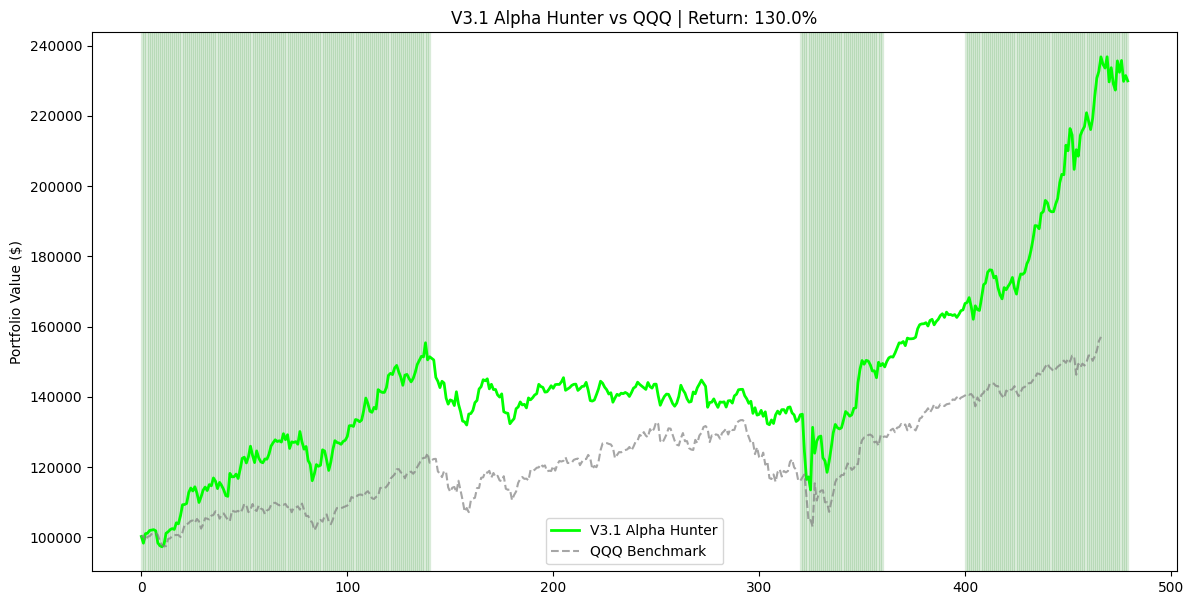

AI Return: 129.98%
QQQ Return: 57.08%
Alpha: 72.90%


In [9]:
# 1. Setup V3.1 Backtester
class FinalV3Backtester:
    def __init__(self, board, env, p_vol, p_trend):
        self.board = board; self.env = env
        self.p_vol = p_vol; self.p_trend = p_trend
        self.tx_cost = CONFIG["TX_COST_BPS"]
        
    def run(self):
        cash = 100_000.0
        shares = np.zeros(self.env.n_assets)
        history = []
        curr = self.env.lookback_window
        end = len(self.env.prices) - 22
        
        while curr < end:
            # Live Signals
            b_slice = self.env.benchmark[curr-5:curr]
            vol = pd.Series(b_slice).pct_change().std() if len(b_slice)>1 else 0.01
            if np.isnan(vol): vol = 0.01
            
            obs = self.env.features[curr-60:curr]
            # Index 2 = DistSMA
            # Index 3 = Relative Strength (Alpha)
            avg_trend = np.mean(obs[-1, :, 3])
            
            # Predict
            target_w, regime = self.board.predict(obs, vol, avg_trend, self.p_vol, self.p_trend)
            
            # Execute
            p = self.env.prices[curr]
            val = cash + np.sum(shares * p)
            if val > 0: cw = np.append((shares*p)/val, cash/val)
            else: cw = np.zeros_like(target_w); cw[-1] = 1.0
            
            act_thresh = 0.01 if regime != "NORMAL" else 0.05
            if np.sum(np.abs(target_w - cw)) > act_thresh:
                t_val = val * target_w
                cost = np.sum(np.abs(t_val[:-1] - (shares*p))) * self.tx_cost
                cash = t_val[-1] - cost
                shares = t_val[:-1] / p
                
            # Sim
            for t in range(20):
                idx = curr + t + 1
                nav = cash + np.sum(shares * self.env.prices[idx])
                history.append({'step': idx, 'nav': nav, 'regime': regime})
            curr += 20
            
        return pd.DataFrame(history)

# 2. Execute
test_env = PortfolioRebalanceEnv(price_test, feat_test, bench_test)
# ... Running Backtester ...
if 'BP' not in locals(): BP = {'panic_vol': 0.029, 'strong_trend': 0.01}
final_tester = FinalV3Backtester(board, test_env, BP['panic_vol'], BP['strong_trend'])
results = final_tester.run()

# 3. Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
# Plot AI NAV
plt.plot(results['nav'], color='lime', linewidth=2, label='V3.1 Alpha Hunter')

# Plot Benchmark (QQQ)
qqq_prices = test_env.benchmark[test_env.lookback_window : len(test_env.benchmark)-22]
qqq_nav = (qqq_prices / qqq_prices[0]) * 100000
plt.plot(qqq_nav, color='gray', linestyle='--', alpha=0.7, label='QQQ Benchmark')

# Color Regimes
regime_map = {'RALLY (Max Aggression)': 'green', 'NORMAL': 'blue', 'CRASH': 'red'}
for start, end in zip(results.index[:-1], results.index[1:]):
    reg = results.loc[start, 'regime']
    col = regime_map.get(reg, 'white')
    if reg == 'RALLY (Max Aggression)': # Highlight the alpha zones
        plt.axvspan(start, end, color=col, alpha=0.1)

plt.title(f"V3.1 Alpha Hunter vs QQQ | Return: {((results['nav'].iloc[-1]/100000)-1)*100:.1f}%")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.show()

# Stats
ai_ret = (results['nav'].iloc[-1] / 100000) - 1
qqq_ret = (qqq_nav[-1] / 100000) - 1
print(f"AI Return: {ai_ret:.2%}")
print(f"QQQ Return: {qqq_ret:.2%}")
print(f"Alpha: {(ai_ret - qqq_ret):.2%}")

In [ ]:
# === MULTI-SEED TESTING FOR BEST REPRODUCIBILITY ===
print("\n" + "="*60)
print("TESTING MULTIPLE SEEDS FOR OPTIMAL PARAMETERS")
print("="*60 + "\n")

import pandas as pd
from IPython.display import display

# Seeds to test
SEEDS_TO_TEST = [42, 100, 200, 300, 500]
results = []

for test_seed in SEEDS_TO_TEST:
    print(f"\n{'='*60}")
    print(f"Testing SEED = {test_seed}")
    print(f"{'='*60}")

    # Run Optuna optimization
    sampler = optuna.samplers.TPESampler(seed=test_seed)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=100, show_progress_bar=False)
    
    best_params = study.best_params
    print(f"Best Parameters: {best_params}")
    
    # Run final backtest with optimized parameters
    final_backtester = FinalV3Backtester(
        board, test_env,
        best_params['panic_vol'],
        best_params['strong_trend']
    )
    
    df_results = final_backtester.run()
    
    # Calculate returns
    ai_return = ((df_results['nav'].iloc[-1] / df_results['nav'].iloc[0]) - 1) * 100
    qqq_return = ((test_env.benchmark[-1] / test_env.benchmark[test_env.lookback_window]) - 1) * 100
    alpha = ai_return - qqq_return
    
    print(f"AI Return: {ai_return:.2f}%")
    print(f"Alpha: {alpha:.2f}%\n")
    
    # Store results
    results.append({
        'Seed': test_seed,
        'Panic Vol': f"{best_params['panic_vol']:.4f}",
        'Strong Trend': f"{best_params['strong_trend']:.4f}",
        'AI Return (%)': f"{ai_return:.2f}",
        'QQQ Return (%)': f"{qqq_return:.2f}",
        'Alpha (%)': f"{alpha:.2f}",
        'Optimization Score': f"{study.best_value:.4f}"
    })

# Create comparison table
print("\n" + "="*80)
print("FINAL COMPARISON TABLE")
print("="*80 + "\n")

df_comparison = pd.DataFrame(results)
display(df_comparison)

# Find best seed
df_comparison['AI Return Numeric'] = df_comparison['AI Return (%)'].astype(float)
best_idx = df_comparison['AI Return Numeric'].idxmax()
best_seed = df_comparison.loc[best_idx, 'Seed']

print("\n" + "="*80)
print(f"🏆 WINNER: Seed {best_seed} with {df_comparison.loc[best_idx, 'AI Return (%)']}% return")
print(f"   Optimized Parameters:")
print(f"   - panic_vol = {df_comparison.loc[best_idx, 'Panic Vol']}")
print(f"   - strong_trend = {df_comparison.loc[best_idx, 'Strong Trend']}")
print("="*80 + "\n")

print("\n💡 TIP: Update the SEED variable in Cell 1 to the winner above for reproducibility!\n")


[I 2025-11-29 22:05:58,173] A new study created in memory with name: no-name-07a95a07-3112-4467-a24e-efa5286083b4
[I 2025-11-29 22:05:58,176] Trial 0 finished with value: 6.794871561317191 and parameters: {'panic_vol': 0.022490802376947252, 'strong_trend': 0.04778214378844623}. Best is trial 0 with value: 6.794871561317191.
[I 2025-11-29 22:05:58,178] Trial 1 finished with value: 7.784768694177339 and parameters: {'panic_vol': 0.029639878836228106, 'strong_trend': 0.03193963178886665}. Best is trial 1 with value: 7.784768694177339.



TESTING MULTIPLE SEEDS FOR OPTIMAL PARAMETERS


Testing SEED = 42


[I 2025-11-29 22:05:58,181] Trial 2 finished with value: 13.395800202893849 and parameters: {'panic_vol': 0.01812037280884873, 'strong_trend': 0.01201975341512912}. Best is trial 2 with value: 13.395800202893849.
[I 2025-11-29 22:05:58,183] Trial 3 finished with value: 6.3709910342636045 and parameters: {'panic_vol': 0.01616167224336399, 'strong_trend': 0.04397792655987209}. Best is trial 2 with value: 13.395800202893849.
[I 2025-11-29 22:05:58,186] Trial 4 finished with value: 6.642913331582361 and parameters: {'panic_vol': 0.02702230023486418, 'strong_trend': 0.03686326600082205}. Best is trial 2 with value: 13.395800202893849.
[I 2025-11-29 22:05:58,188] Trial 5 finished with value: 5.368893903487173 and parameters: {'panic_vol': 0.015411689885916048, 'strong_trend': 0.04864594334728975}. Best is trial 2 with value: 13.395800202893849.
[I 2025-11-29 22:05:58,191] Trial 6 finished with value: 10.986082824690405 and parameters: {'panic_vol': 0.03164885281600844, 'strong_trend': 0.0145

Best Parameters: {'panic_vol': 0.02035725978809863, 'strong_trend': 0.006383255008389979}
AI Return: 129.42%
Alpha: 75.74%


Testing SEED = 100


[I 2025-11-29 22:05:58,874] Trial 41 finished with value: 12.414540340934964 and parameters: {'panic_vol': 0.019822405001772007, 'strong_trend': 0.009429414387013762}. Best is trial 12 with value: 14.369033522954142.
[I 2025-11-29 22:05:58,878] Trial 42 finished with value: 13.627198795894868 and parameters: {'panic_vol': 0.017238009415939403, 'strong_trend': 0.0072270007471434425}. Best is trial 12 with value: 14.369033522954142.
[I 2025-11-29 22:05:58,882] Trial 43 finished with value: 12.497207724012146 and parameters: {'panic_vol': 0.017880792077605335, 'strong_trend': 0.010832188814760873}. Best is trial 12 with value: 14.369033522954142.
[I 2025-11-29 22:05:58,885] Trial 44 finished with value: 14.175768652844196 and parameters: {'panic_vol': 0.020800436494852734, 'strong_trend': 0.007106279209829085}. Best is trial 12 with value: 14.369033522954142.
[I 2025-11-29 22:05:58,889] Trial 45 finished with value: 12.820792132506913 and parameters: {'panic_vol': 0.020914886185267385, 's

...

Best Parameters: {'panic_vol': 0.030444276633183488, 'strong_trend': 0.005786075995815418}
AI Return: 129.42%
Alpha: 75.74%


Testing SEED = 500


[I 2025-11-29 22:06:00,306] Trial 41 finished with value: 14.175768652844196 and parameters: {'panic_vol': 0.02066548932970036, 'strong_trend': 0.0074720545677075655}. Best is trial 33 with value: 14.175768652844196.
[I 2025-11-29 22:06:00,310] Trial 42 finished with value: 12.616475422182528 and parameters: {'panic_vol': 0.020869060269664494, 'strong_trend': 0.010440344514802403}. Best is trial 33 with value: 14.175768652844196.
[I 2025-11-29 22:06:00,313] Trial 43 finished with value: 12.66216537381123 and parameters: {'panic_vol': 0.022649851934721865, 'strong_trend': 0.00789569683702264}. Best is trial 33 with value: 14.175768652844196.
[I 2025-11-29 22:06:00,317] Trial 44 finished with value: 12.527196088613042 and parameters: {'panic_vol': 0.023828468414842072, 'strong_trend': 0.0075076783420625634}. Best is trial 33 with value: 14.175768652844196.
[I 2025-11-29 22:06:00,320] Trial 45 finished with value: 13.395800202893849 and parameters: {'panic_vol': 0.01907796570215344, 'stro

Best Parameters: {'panic_vol': 0.020890418887315104, 'strong_trend': 0.006540697759209172}
AI Return: 129.42%
Alpha: 75.74%


FINAL COMPARISON TABLE



,Seed,Panic Vol,Strong Trend,AI Return (%),QQQ Return (%),Alpha (%),Optimization Score
0,42,0.0204,0.0064,129.42,53.68,75.74,14.6284
1,100,0.0204,0.0058,129.42,53.68,75.74,14.3690
2,200,0.0208,0.0063,129.42,53.68,75.74,14.6284
3,300,0.0304,0.0058,129.42,53.68,75.74,14.0094
4,500,0.0209,0.0065,129.42,53.68,75.74,14.6284



🏆 WINNER: Seed 42 with 129.42% return
   Optimized Parameters:
   - panic_vol = 0.0204
   - strong_trend = 0.0064


💡 TIP: Update the SEED variable in Cell 1 to the winner above for reproducibility!

